In [2]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

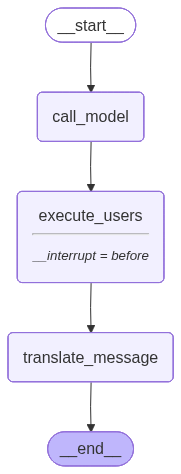

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import json
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,AIMessage

class State(TypedDict):
    user_input:str
    model_response:str
    user_approval:str
    
def call_model(state):
    print('call_model start')
    messages=state["user_input"]
    if "删除" in messages:
        state["user_approval"]=f"用户输入的指令丝:{messages},请人工确认是否执行 please approve or reject"
    else:
        response=llm.invoke(messages)
        state["user_approval"]="直接运行"
        state["model_response"]=response
    
    print("call_model end")

    return state

def execute_users(state):
    print("execute_users")
    if state["user_approval"]=="是":
        response="你的删除请求已经获得管理员的批准并成功执行.如果您还有其他问题或需要进一步的帮助，请随时联系我们"
        return {"model_response":AIMessage(response)}
    elif state["user_approval"]=="否":
        response="对不起，您当前的请求丝危险操作，管理员不允许执行"
        return{"user_approval":AIMessage(response)}
    else:
        return state

def translate_message(state:State):
    print("translate_message start")
    system_prompt="""
    please translate the received text in any language into Englis as output"""
    
    messages=state["model_response"]
    messages=[SystemMessage(content=system_prompt)]+[HumanMessage(content=messages.content)]
    response=llm.invoke(messages)
    print("translate_message end")
    return {"model_response":response}

builder=StateGraph(State)

builder.add_node("call_model",call_model)
builder.add_node("execute_users",execute_users)
builder.add_node("translate_message",translate_message)

builder.add_edge(START,"call_model")
builder.add_edge("call_model","execute_users")
builder.add_edge("execute_users","translate_message")
builder.add_edge("translate_message",END)

memory=MemorySaver()

graph=builder.compile(checkpointer=memory,interrupt_before=["execute_users"])

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

    
        

In [4]:
config={"configurable":{"thread_id":"3"}}

async for chunk in graph.astream({"user_input":"我将在数据库中删除id为xigualaosi的所有信息"},config,stream_mode="values"):
    print(chunk)
    

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息'}
call_model start
call_model end
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '用户输入的指令丝:我将在数据库中删除id为xigualaosi的所有信息,请人工确认是否执行 please approve or reject'}


In [5]:
snapshot=graph.get_state(config)
snapshot

StateSnapshot(values={'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '用户输入的指令丝:我将在数据库中删除id为xigualaosi的所有信息,请人工确认是否执行 please approve or reject'}, next=('execute_users',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f16e030-9f8b-68be-8001-41f69e708260'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-22T06:24:35.644844+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f16e030-9f83-6e77-8000-9f7580ddf4e9'}}, tasks=(PregelTask(id='c6717735-27de-78e3-d320-1862e1e59dd5', name='execute_users', path=('__pregel_pull', 'execute_users'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [6]:
snapshot.values["user_approval"]="是"
graph.update_state(config,snapshot.values)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16e030-9fd2-6a21-8002-d5464bbbbe8e'}}

In [7]:
async for chunk in graph.astream(None,config,stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '是'}
execute_users
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='你的删除请求已经获得管理员的批准并成功执行.如果您还有其他问题或需要进一步的帮助，请随时联系我们', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), 'user_approval': '是'}
translate_message start
translate_message end
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 42, 'total_tokens': 73, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 42}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 

In [8]:
config={"configurable":{"thread_id":"3"}}

async for chunk in graph.astream({"user_input":"我将在数据库中删除id为xigualaosi的所有信息"},config,stream_mode="values"):
    print(chunk)
    

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 42, 'total_tokens': 73, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 42}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '206f2af0-a26d-463b-967f-060f105cd777', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eee00-93e6-77e1-af62-e415da423642-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 31, 'total_tokens': 73, 'input_token_details': {'cache_read': 0}

In [9]:
snapshot=graph.get_state(config)

In [10]:
snapshot.values["user_approval"]="否"
graph.update_state(config,snapshot.values)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16e030-aa43-6696-8008-54a310ee2e25'}}

In [11]:
async for chunk in graph.astream(None,config,stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 42, 'total_tokens': 73, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 42}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '206f2af0-a26d-463b-967f-060f105cd777', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eee00-93e6-77e1-af62-e415da423642-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 31, 'total_tokens': 73, 'input_token_details': {'cache_read': 0}

In [12]:
config={"configurable":{"thread_id":"5"}}

async for chunk in graph.astream({"user_input":"你好，请你介绍一下你自己"},config,stream_mode="values"):
    print(f"start: {chunk}")

# async for chunk in graph.astream(None,config,stream_mode="values"):
#     print(chunk)

start: {'user_input': '你好，请你介绍一下你自己'}
call_model start
call_model end
start: {'user_input': '你好，请你介绍一下你自己', 'model_response': AIMessage(content='你好呀！很高兴认识你！😊\n\n我是 **DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：\n\n**我能做什么？**\n- 📝 **文字处理**：写作、翻译、总结、改写等各种文本任务\n- 💡 **知识问答**：从科学到历史，从技术到生活常识，我都能聊\n- 📄 **文件阅读**：支持上传图片、PDF、Word、Excel、PPT等文件，帮你提取和分析信息\n- 🔗 **链接阅读**：可以读取网页链接内容（需要你手动开启联网搜索功能）\n- 🧮 **编程辅助**：代码编写、调试、解释，各种编程语言都懂一些\n- 🎯 **逻辑推理**：帮你分析问题、头脑风暴、制定计划\n\n**我的特点：**\n- ✅ **完全免费**：没有收费计划，放心使用\n- ✅ **超长上下文**：1M token容量，可以一次性处理像《三体》三部曲那么长的内容\n- ✅ **多平台支持**：网页版、App版都有，App还支持语音输入\n- ✅ **知识更新**：知识截止到2025年5月\n\n**小提示：**\n- 我是纯文本模型，不能直接“看”图片，但可以读取图片中的文字信息\n- 如果需要联网搜索最新信息，记得在界面上手动开启联网功能哦\n\n有什么我可以帮你的吗？无论是学习、工作还是日常闲聊，我都很乐意陪你聊！🌟', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 321, 'prompt_tokens': 9, 'total_tokens': 330, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prom

In [13]:
def run_dialogue(graph,config,all_chunks=[]):
    while True:
        
        user_input=input("请输入您的消息(输入‘退出’结束对话):")
        if user_input.lower() == '退出':
            break
        
        for chunk in graph.stream({"user_input":user_input},config,stream_mode="values"):
            all_chunks.append(chunk)
            
        last_chunk = all_chunks[-1]
        print("last_chunk start")
        print(last_chunk)
        print(last_chunk["user_approval"])
        if "please approve or reject" in last_chunk["user_approval"]:
            user_approval=input(f"当前用户的输入是：{last_chunk['user_input']},请人工确认是否执行！请回复 是/否。")
            graph.update_state(config,{"user_approval":user_approval})
            
        for chunk in graph.stream(None,config,stream_mode="values"):
            all_chunks.append(chunk)
            
        print("人工智能助理：",all_chunks[-1]["model_response"].content)

In [14]:
config={"configurable":{"thread_id":"6"}}

run_dialogue(graph,config)

call_model start
call_model end
last_chunk start
{'user_input': '介绍一下自己', 'model_response': AIMessage(content='你好呀！很高兴认识你！👋\n\n我是**DeepSeek**，由深度求索公司创造的AI助手。让我简单介绍一下自己：\n\n## 🌟 我的特点\n\n- **完全免费**：没错，我不收费！可以随时随地为你提供帮助\n- **超强上下文**：拥有1M的上下文长度，可以一次性处理像《三体》三部曲那么厚的书籍\n- **多格式支持**：能处理图片、PDF、Word、Excel、PPT等文件，从中提取文字信息\n- **联网搜索**：需要时可以帮你搜索最新信息（需要手动开启）\n- **语音输入**：App端支持语音交流\n\n## 💬 我能做什么\n\n- 回答各种问题，从日常咨询到专业领域\n- 帮你写作、翻译、编程、分析数据\n- 阅读和分析你上传的文档\n- 陪你聊天、头脑风暴\n\n## 📱 如何使用\n\n你可以通过官方应用商店下载App，或者在网页端使用我。\n\n我的知识截止于2025年5月，虽然不能实时更新，但开启联网搜索功能后就能获取最新信息啦！\n\n有什么我可以帮你的吗？无论是学习、工作还是生活上的问题，尽管问我！😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 254, 'prompt_tokens': 6, 'total_tokens': 260, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 6}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_